In [2]:
from common import SystemConfig
from dynamics import ContinuousLQREnv

import matplotlib.pyplot as plt
import numpy as np

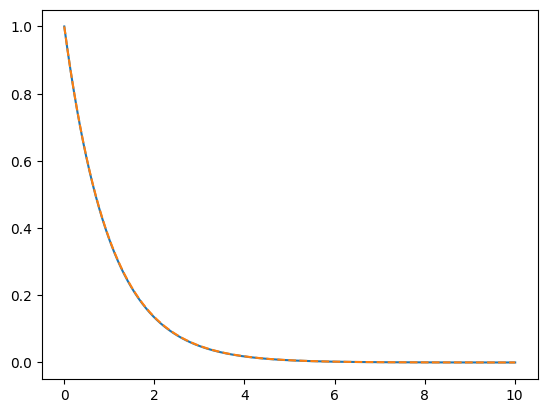

In [14]:
# Sanity check: x'(t) = -x(t) should give exp(-t)
A = np.array([[-1.0]])
B = np.array([[0.0]])
sigma = np.array([[0.0]])
config = SystemConfig(x_dim=1, u_dim=1, dt=0.01, T=10, s_A=None, s_B=None, sigma=None, a_scale=None, b_scale=None, coeff_lower=None, max_instability=None)
env = ContinuousLQREnv(A, B, sigma, config.dt)

t = 0.0
x = np.array([1.0])
u = np.array([0.0])
sigma_u = np.array([0.0])
t_vals = [t]
x_vals = [x.item()]

while t < config.T:
    t += config.dt
    x = env.step(x, u, sigma_u)
    t_vals.append(t)
    x_vals.append(x.item())

plt.plot(t_vals, x_vals)
plt.plot(t_vals, np.exp(-np.array(t_vals)), linestyle='--')
plt.show()